In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/heart/heart_disease_uci.csv")
print(data.head())

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  


In [4]:
print(data.shape)

(920, 16)


In [5]:
print(data.columns)

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')


In [6]:
print(data.info)

<bound method DataFrame.info of       id  age     sex        dataset               cp  trestbps   chol    fbs  \
0      1   63    Male      Cleveland   typical angina     145.0  233.0   True   
1      2   67    Male      Cleveland     asymptomatic     160.0  286.0  False   
2      3   67    Male      Cleveland     asymptomatic     120.0  229.0  False   
3      4   37    Male      Cleveland      non-anginal     130.0  250.0  False   
4      5   41  Female      Cleveland  atypical angina     130.0  204.0  False   
..   ...  ...     ...            ...              ...       ...    ...    ...   
915  916   54  Female  VA Long Beach     asymptomatic     127.0  333.0   True   
916  917   62    Male  VA Long Beach   typical angina       NaN  139.0  False   
917  918   55    Male  VA Long Beach     asymptomatic     122.0  223.0   True   
918  919   58    Male  VA Long Beach     asymptomatic       NaN  385.0   True   
919  920   62    Male  VA Long Beach  atypical angina     120.0  254.0  False

In [7]:
print(data.describe)

<bound method NDFrame.describe of       id  age     sex        dataset               cp  trestbps   chol    fbs  \
0      1   63    Male      Cleveland   typical angina     145.0  233.0   True   
1      2   67    Male      Cleveland     asymptomatic     160.0  286.0  False   
2      3   67    Male      Cleveland     asymptomatic     120.0  229.0  False   
3      4   37    Male      Cleveland      non-anginal     130.0  250.0  False   
4      5   41  Female      Cleveland  atypical angina     130.0  204.0  False   
..   ...  ...     ...            ...              ...       ...    ...    ...   
915  916   54  Female  VA Long Beach     asymptomatic     127.0  333.0   True   
916  917   62    Male  VA Long Beach   typical angina       NaN  139.0  False   
917  918   55    Male  VA Long Beach     asymptomatic     122.0  223.0   True   
918  919   58    Male  VA Long Beach     asymptomatic       NaN  385.0   True   
919  920   62    Male  VA Long Beach  atypical angina     120.0  254.0  Fal

In [9]:
print(data.isnull().sum())

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [19]:
data.fillna(data.mean(numeric_only=True), inplace=True)

In [20]:
print(data.isnull().sum())

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
num         0
dtype: int64


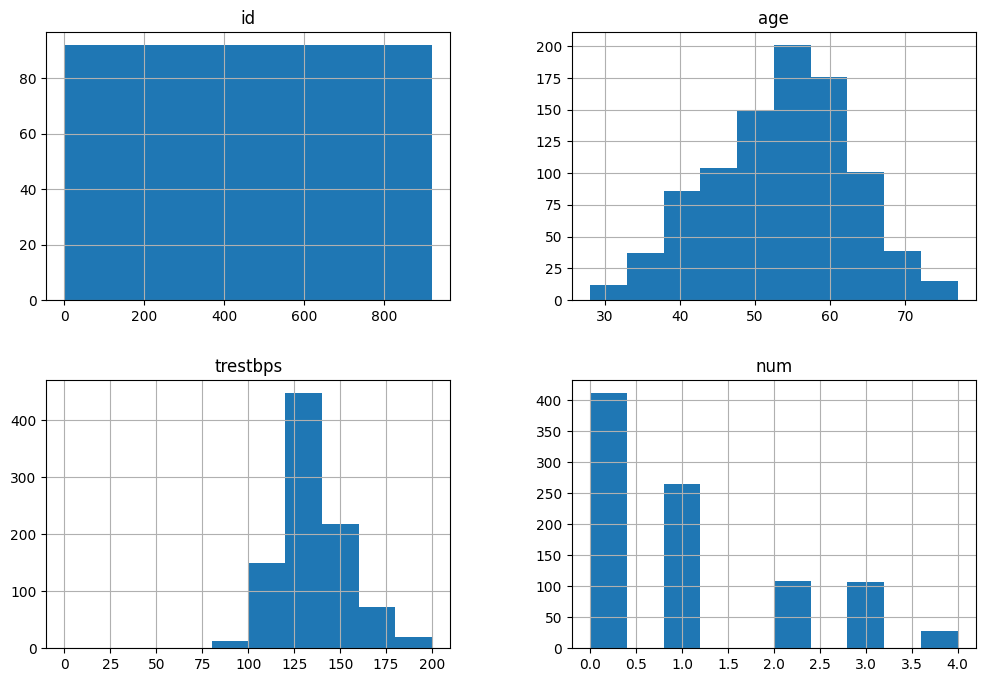

In [21]:
data.hist(figsize=(12,8))

plt.show()

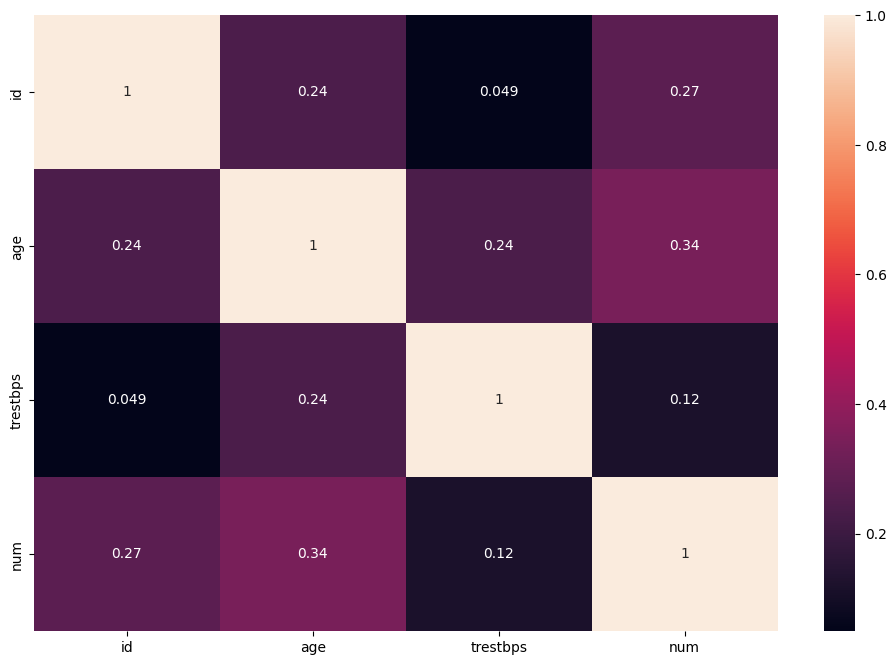

In [23]:
plt.figure(figsize=(12,8))

# sirf numeric columns select karo
numeric_data = data.select_dtypes(include=['number'])

# heatmap
sns.heatmap(numeric_data.corr(), annot=True)

plt.show()

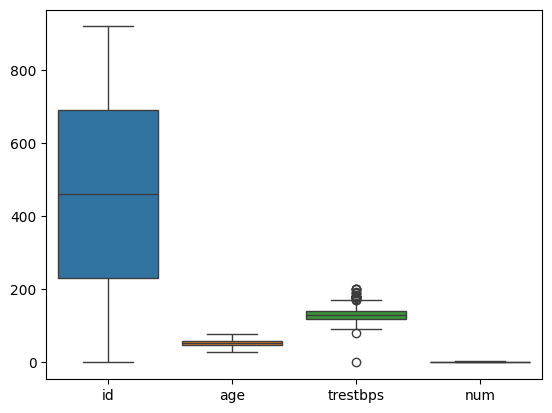

In [24]:
sns.boxplot(data=data)

plt.show()

In [26]:
# input features
X = data.drop("num", axis=1)

# output/target
y = data["num"]

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
print(data.select_dtypes(include='object').columns)

Index(['sex', 'dataset', 'cp'], dtype='object')


In [30]:
# Male/Female convert
data["sex"] = data["sex"].map({
    "Male": 1,
    "Female": 0
})

# dataset column convert
data["dataset"] = data["dataset"].astype("category").cat.codes

In [31]:
X = data.drop("num", axis=1)

y = data["num"]

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
X_train.dtypes

,0
id,int64
age,int64
sex,int64
dataset,int8
cp,object
trestbps,float64


In [37]:
X_train['cp'].unique()

array(['asymptomatic', 'non-anginal', 'atypical angina', 'typical angina'],
      dtype=object)

In [38]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

cp_encoded_train = ohe.fit_transform(X_train[['cp']])
cp_encoded_test = ohe.transform(X_test[['cp']])

In [39]:
import pandas as pd

# drop old column
X_train = X_train.drop('cp', axis=1)
X_test = X_test.drop('cp', axis=1)

# add encoded columns
X_train = pd.concat([
    X_train.reset_index(drop=True),
    pd.DataFrame(cp_encoded_train)
], axis=1)

X_test = pd.concat([
    X_test.reset_index(drop=True),
    pd.DataFrame(cp_encoded_test)
], axis=1)

In [42]:
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

In [43]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [44]:
y_pred = model.predict(X_test)

print(y_pred)

[0 0 1 0 1 0 1 1 1 0 0 1 1 1 2 0 0 1 0 1 0 0 0 0 1 2 1 0 2 0 0 0 0 0 0 1 0
 1 0 0 1 0 0 0 0 1 1 0 0 0 0 0 1 2 0 0 1 0 0 1 0 0 1 1 0 1 0 1 1 0 0 0 1 0
 0 0 0 1 0 0 0 1 0 1 1 1 1 2 0 0 1 2 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 1 0 0 1
 0 0 0 0 0 1 0 1 1 0 1 0 1 1 0 1 0 1 0 0 0 0 0 1 0 0 2 1 0 0 1 1 1 1 1 1 1
 0 0 1 2 0 1 0 2 0 0 1 0 1 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 2]


In [45]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.4945652173913043


In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[64 11  0  0  0]
 [23 26  5  0  0]
 [ 9 15  1  0  0]
 [12 10  4  0  0]
 [ 2  2  0  0  0]]


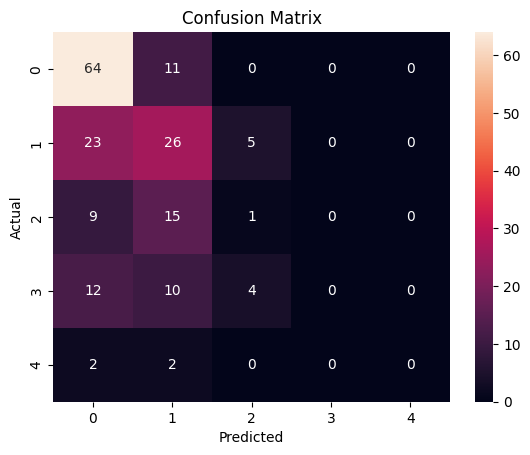

In [47]:
sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [50]:
print(y_test.unique())

[0 1 3 2 4]


In [51]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Convert multiclass labels to binary matrix
y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4])

# Probability predictions
y_prob = model.predict_proba(X_test)

# Multiclass AUC
auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')

print("Multiclass AUC Score:", auc)

Multiclass AUC Score: 0.6522169791812723
